In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report


In [34]:
import os
os.listdir()

from google.colab import files
uploaded = files.upload()

Saving student-mat.csv to student-mat (1).csv


In [39]:
import pandas as pd

df = pd.read_csv("/content/student-mat (1).csv", sep=';')

df.head()


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


In [40]:
def risk_category(score):
    if score < 10:
        return "High"
    elif score < 15:
        return "Moderate"
    else:
        return "Safe"

df["risk_level"] = df["G3"].apply(risk_category)
df[["G3","risk_level"]].head()

,G3,risk_level
0,6,High
1,6,High
2,10,Moderate
3,15,Safe
4,10,Moderate


counting risk


In [41]:
df["risk_level"].value_counts()

,count
risk_level,
Moderate,192
High,130
Safe,73


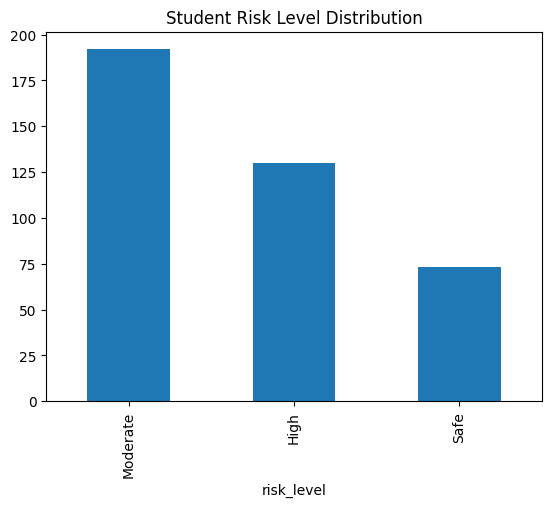

In [42]:
import matplotlib.pyplot as plt

df['risk_level'].value_counts().plot(kind='bar')

plt.title("Student Risk Level Distribution")
plt.show()

conv risk to num

In [43]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

df["risk_encoded"] = encoder.fit_transform(df["risk_level"])

df[["risk_level","risk_encoded"]].head()

X = df[['studytime','failures','absences','G1','G2']]

y = df['risk_encoded']

train and testing

In [44]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

training random forest

In [45]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators=100)

model.fit(X_train, y_train)

RandomForestClassifier()

predict stud risk and accuracy

In [46]:
y_pred = model.predict(X_test)
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", accuracy)

Model Accuracy: 0.8734177215189873


report from model

In [47]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.83      0.93      0.88        27
           1       0.84      0.84      0.84        32
           2       1.00      0.85      0.92        20

    accuracy                           0.87        79
   macro avg       0.89      0.87      0.88        79
weighted avg       0.88      0.87      0.87        79



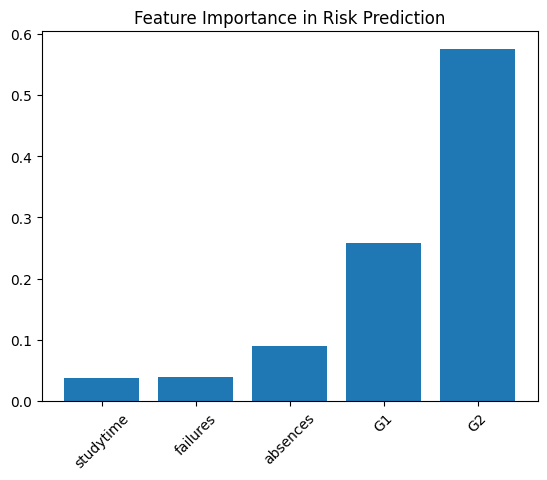

In [48]:
import matplotlib.pyplot as plt

importance = model.feature_importances_

features = X.columns

plt.bar(features, importance)

plt.title("Feature Importance in Risk Prediction")

plt.xticks(rotation=45)

plt.show()

predicting for new students

In [49]:
sample = [[2,0,5,12,13]]

prediction = model.predict(sample)

encoder.inverse_transform(prediction)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


array(['Moderate'], dtype=object)

NLP WORK

In [50]:
from textblob import TextBlob

text = "I find mathematics difficult but I like science."

analysis = TextBlob(text)

print("Sentiment Score:", analysis.sentiment)

Sentiment Score: Sentiment(polarity=-0.5, subjectivity=1.0)


confusion matrix (vizual)

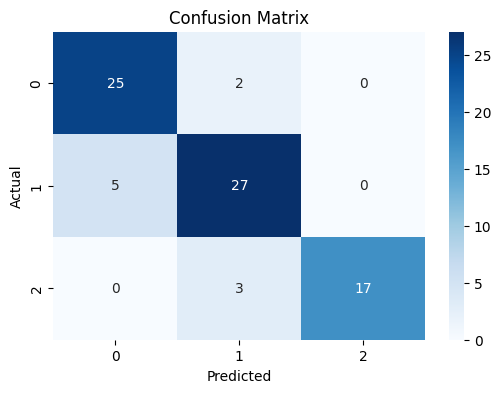

In [51]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

previous grades influences risk prediction

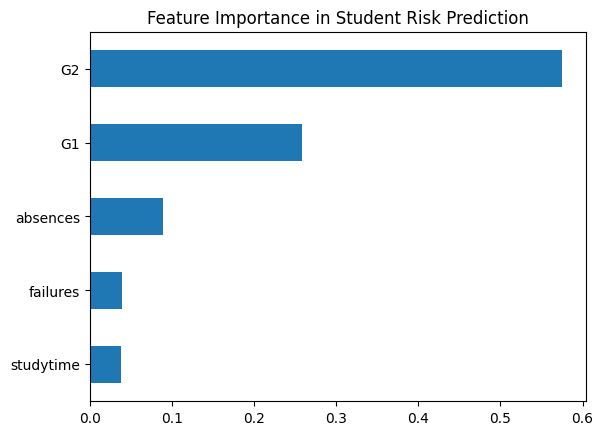

In [52]:
import pandas as pd

feature_importance = pd.Series(model.feature_importances_, index=X.columns)

feature_importance.sort_values().plot(kind='barh')

plt.title("Feature Importance in Student Risk Prediction")

plt.show()

In [53]:
def knowledge_gap(row):
    gaps = []

    if row['G1'] < 10:
        gaps.append("Weak in early assessments")

    if row['G2'] < 10:
        gaps.append("Struggling with midterm concepts")

    if row['absences'] > 10:
        gaps.append("High absenteeism affecting learning")

    if row['studytime'] < 2:
        gaps.append("Low study time")

    return gaps

decision support by AI

In [54]:
student = df.iloc[0]

knowledge_gap(student)

['Weak in early assessments', 'Struggling with midterm concepts']

In [55]:
def predict_student_risk(studytime, failures, absences, G1, G2):

    sample = [[studytime, failures, absences, G1, G2]]

    prediction = model.predict(sample)

    result = encoder.inverse_transform(prediction)

    return result[0]
    predict_student_risk(2,0,5,12,13)

NATURAL LANG PROCESSING (NLP)

In [56]:
!pip install textblob
from textblob import TextBlob


In [58]:
from textblob import TextBlob

# Function for sentiment analysis
def analyze_feedback(feedback):

    analysis = TextBlob(feedback)

    polarity = analysis.sentiment.polarity

    if polarity > 0:
        sentiment = "Positive"
    elif polarity == 0:
        sentiment = "Neutral"
    else:
        sentiment = "Negative"

    return sentiment, polarity


# Test the function (this must be OUTSIDE the function)
feedback = "I find mathematics difficult and I struggle to understand the lessons"

sentiment, score = analyze_feedback(feedback)

print("Feedback:", feedback)
print("Sentiment:", sentiment)
print("Sentiment Score:", score)

Feedback: I find mathematics difficult and I struggle to understand the lessons
Sentiment: Negative
Sentiment Score: -0.5


In [59]:
import pickle
pickle.dump(model, open("student_risk_model.pkl", "wb"))